                                    A/B测试与营销效果评估

一、环境准备与数据导入

1.1 数据说明
数据源：Kaggle"A/B Testing Dataset" 包含：

user_id：用户唯一标识

timestamp：用户访问时间

group：用户所在分组（control 对照组=旧页面，treatment 实验组=新页面）

landing_page：用户实际看到的页面（old_page 或 new_page）

converted：是否转化（0=未转化，1=转化）

1.2 导入库并读取数据

In [1]:
# ========== 导入所有需要的库 ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
font = FontProperties(fname="/home/041f5dea-40df-408c-b3a3-c6dae4b19638/fonts/simhei.ttf")   #字体路径
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

# 设置画图参数
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# ========== 读取数据 ==========
df = pd.read_csv('ab_data.csv')
print(f"数据量: {df.shape}")
print(f"\n列名: {df.columns.tolist()}")
df.head(10)

数据量: (294478, 5)

列名: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
5,936923,2017-01-10 15:20:49.083499,control,old_page,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1


1.3 数据初探

In [2]:
# 基本信息
print("========== 数据信息 ==========")
df.info()

print("\n========== 缺失值 ==========")
print(df.isnull().sum())

print("\n========== 各组样本量 ==========")
print(df['group'].value_counts())

print("\n========== landing_page分布 ==========")
print(df['landing_page'].value_counts())

print("\n========== 转化率概览 ==========")
print(f"整体转化率: {df['converted'].mean()*100:.2f}%")

========== 数据信息 ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB

========== 缺失值 ==========
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

========== 各组样本量 ==========
group
treatment    147276
control      147202
Name: count, dtype: int64

========== landing_page分布 ==========
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

========== 转化率概览 ==========
整体转化率: 11.97%


结果：
数据约29万行，没有缺失值。
group 中 control 和 treatment 各约14.5万，看起来是50:50随机分配。
但 landing_page 的分布需要和 group 交叉验证。

二、实验质量检查

2.1 检查分组与实际看到页面是否一致

In [3]:
# 交叉表：分组 vs 实际页面
confusion = pd.crosstab(df['group'], df['landing_page'], margins=True, margins_name='Total')
print("========== 分组 vs 实际页面 交叉表 ==========")
print(confusion)

# 找出不一致的记录
mismatch = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]
print(f"\n分组与实际页面不一致的记录数: {len(mismatch)}")
print(f"不一致比例: {len(mismatch)/len(df)*100:.3f}%")

========== 分组 vs 实际页面 交叉表 ==========
landing_page  new_page  old_page   Total
group                                   
control           1928    145274  147202
treatment       145311      1965  147276
Total           147239    147239  294478

分组与实际页面不一致的记录数: 3893
不一致比例: 1.322%


结果：发现有约3,900条记录不一致（约1.3%），比如被分到control组却看到了new_page。这是实验执行中的污染，需要处理。

2.2 检查是否有重复用户

In [4]:
# 检查user_id唯一性
total_users = df['user_id'].nunique()
total_records = len(df)
duplicate_users = total_records - total_users

print(f"总记录数: {total_records}")
print(f"唯一用户数: {total_users}")
print(f"重复用户数: {duplicate_users}")

# 找出重复用户
if duplicate_users > 0:
    duplicate_ids = df['user_id'].value_counts()
    duplicate_ids = duplicate_ids[duplicate_ids > 1]
    print(f"\n重复出现的用户数: {len(duplicate_ids)}")
    print(f"其中出现3次以上的: {(duplicate_ids > 2).sum()}")
    
    # 看一个重复用户的例子
    example_id = duplicate_ids.index[0]
    print(f"\n示例重复用户 (user_id={example_id}):")
    print(df[df['user_id'] == example_id])

总记录数: 294478
唯一用户数: 290584
重复用户数: 3894

重复出现的用户数: 3894
其中出现3次以上的: 0

示例重复用户 (user_id=752737):
        user_id                   timestamp      group landing_page  converted
88996    752737  2017-01-14 10:25:51.365583  treatment     old_page          0
154517   752737  2017-01-23 12:00:50.109069    control     old_page          0


结果：发现约3,900名用户出现了两次（刚好和前面不一致记录数量接近——它们很可能是同一批问题用户）。
重复用户会破坏独立性假设，必须删除。

2.3 清洗数据：构建干净的实验数据集

In [5]:
# 步骤1：删除分组与实际页面不一致的记录
df_clean = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
].copy()

print(f"删除不一致记录后: {len(df_clean)} 条")

# 步骤2：删除重复用户（保留第一次出现的记录）
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')
print(f"删除重复用户后: {len(df_clean)} 条")
print(f"唯一用户数: {df_clean['user_id'].nunique()}")

# 确认清洗结果
print("\n========== 清洗后分组分布 ==========")
print(df_clean['group'].value_counts())
print(f"\nControl组占比: {df_clean['group'].value_counts()['control']/len(df_clean)*100:.1f}%")
print(f"Treatment组占比: {df_clean['group'].value_counts()['treatment']/len(df_clean)*100:.1f}%")

删除不一致记录后: 290585 条
删除重复用户后: 290584 条
唯一用户数: 290584

========== 清洗后分组分布 ==========
group
treatment    145310
control      145274
Name: count, dtype: int64

Control组占比: 50.0%
Treatment组占比: 50.0%


2.4 随机性检查：时间维度上分组是否均匀

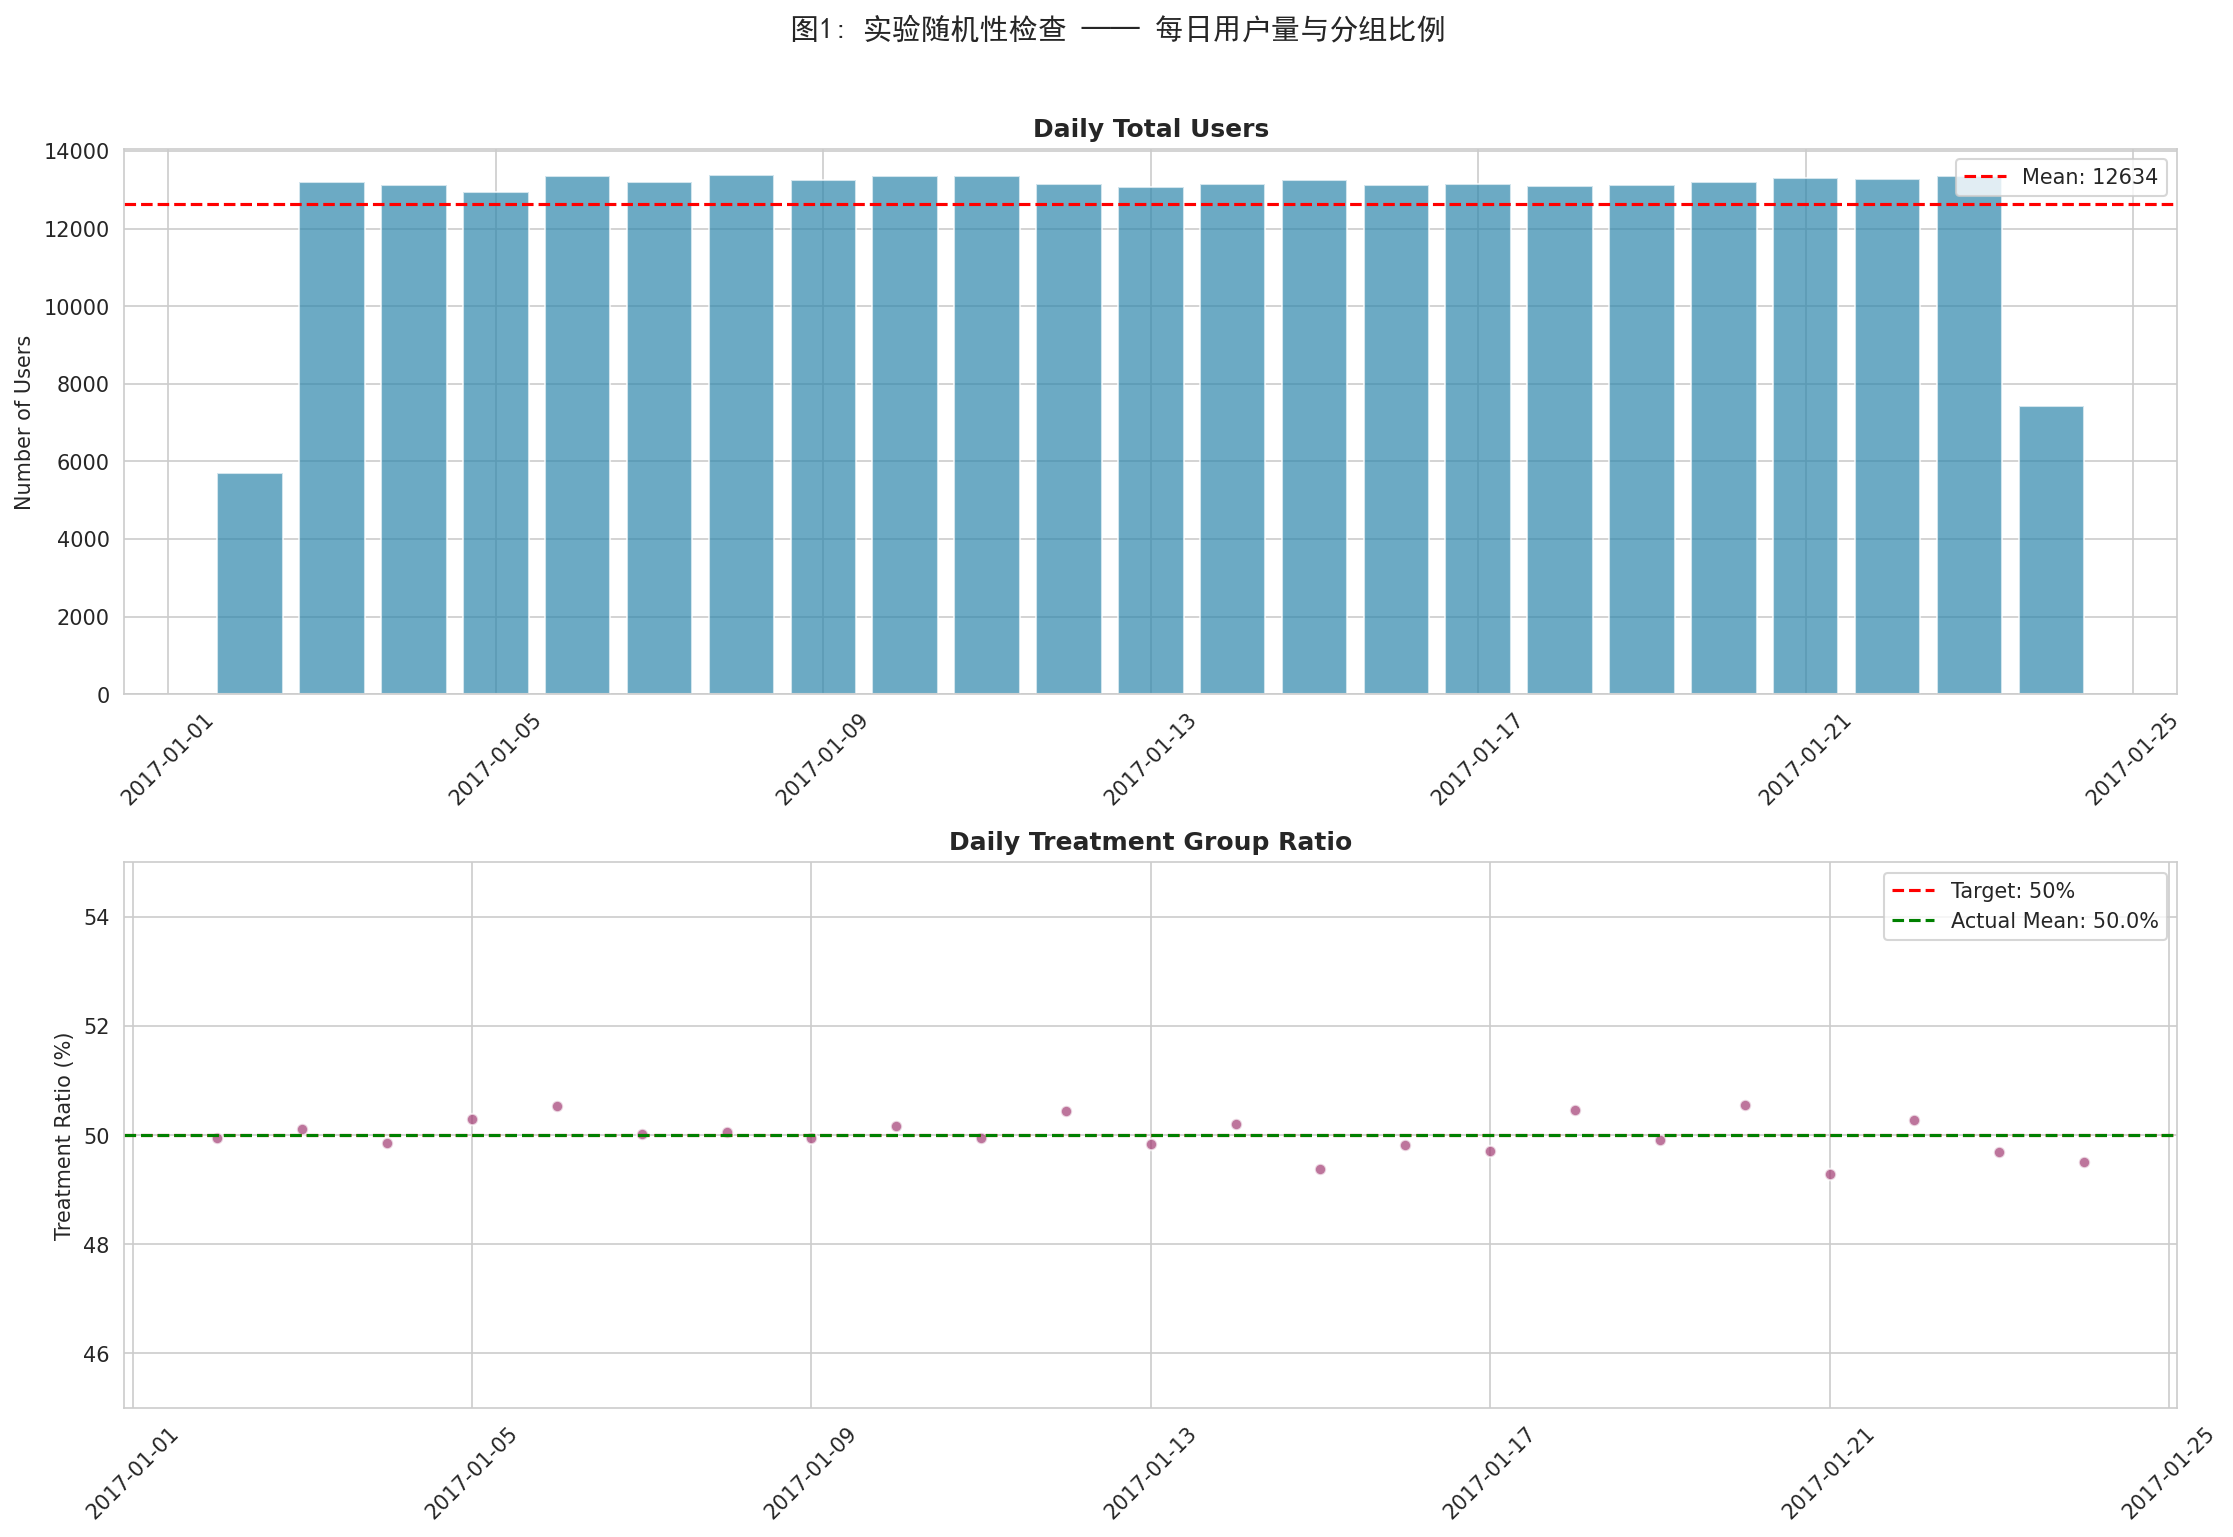

日均用户数: 12634 ± 1933
实验组日均比例: 50.00%


In [6]:
# 将timestamp转为datetime
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['date'] = df_clean['timestamp'].dt.date

# 每天的分组比例
daily_group = df_clean.groupby('date').agg(
    total=('user_id', 'count'),
    treatment_count=('group', lambda x: (x == 'treatment').sum())
).reset_index()
daily_group['treatment_ratio'] = daily_group['treatment_count'] / daily_group['total']

# 画图检查
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 每日总用户数
axes[0].bar(daily_group['date'], daily_group['total'], color='#2E86AB', alpha=0.7, edgecolor='white')
axes[0].axhline(y=daily_group['total'].mean(), color='red', linestyle='--', label=f'Mean: {daily_group["total"].mean():.0f}')
axes[0].set_title('Daily Total Users', fontweight='bold')
axes[0].set_ylabel('Number of Users')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 每日实验组比例
axes[1].scatter(daily_group['date'], daily_group['treatment_ratio']*100, 
                color='#A23B72', alpha=0.7, edgecolors='white', s=30)
axes[1].axhline(y=50, color='red', linestyle='--', label='Target: 50%')
axes[1].axhline(y=daily_group['treatment_ratio'].mean()*100, color='green', linestyle='--', 
                label=f'Actual Mean: {daily_group["treatment_ratio"].mean()*100:.1f}%')
axes[1].set_title('Daily Treatment Group Ratio', fontweight='bold')
axes[1].set_ylabel('Treatment Ratio (%)')
axes[1].set_ylim(45, 55)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('图1: 实验随机性检查 —— 每日用户量与分组比例', fontsize=14, fontweight='bold', y=1.02,fontproperties=font)
plt.tight_layout()
plt.savefig('images/randomization_check.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"日均用户数: {daily_group['total'].mean():.0f} ± {daily_group['total'].std():.0f}")
print(f"实验组日均比例: {daily_group['treatment_ratio'].mean()*100:.2f}%")

三、探索性数据分析（EDA）

3.1 核心指标：两组的转化率对比

In [7]:
# 计算两组的转化率
conversion_rates = df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean'])
conversion_rates.columns = ['Total_Users', 'Conversions', 'Conversion_Rate']
conversion_rates['Conversion_Rate_pct'] = conversion_rates['Conversion_Rate'] * 100
conversion_rates['Non_Conversions'] = conversion_rates['Total_Users'] - conversion_rates['Conversions']

print("========== 分组转化率 ==========")
print(conversion_rates)

# 计算绝对差异
control_rate = conversion_rates.loc['control', 'Conversion_Rate']
treatment_rate = conversion_rates.loc['treatment', 'Conversion_Rate']
observed_diff = treatment_rate - control_rate

print(f"\n对照组转化率: {control_rate*100:.4f}%")
print(f"实验组转化率: {treatment_rate*100:.4f}%")
print(f"观察到的提升: {observed_diff*100:.4f} 个百分点")
print(f"相对提升: {(observed_diff/control_rate)*100:.2f}%")

========== 分组转化率 ==========
           Total_Users  Conversions  Conversion_Rate  Conversion_Rate_pct  \
group                                                                       
control         145274        17489         0.120386            12.038630   
treatment       145310        17264         0.118808            11.880807   

           Non_Conversions  
group                       
control             127785  
treatment           128046  

对照组转化率: 12.0386%
实验组转化率: 11.8808%
观察到的提升: -0.1578 个百分点
相对提升: -1.31%


3.2 可视化：两组的转化率对比

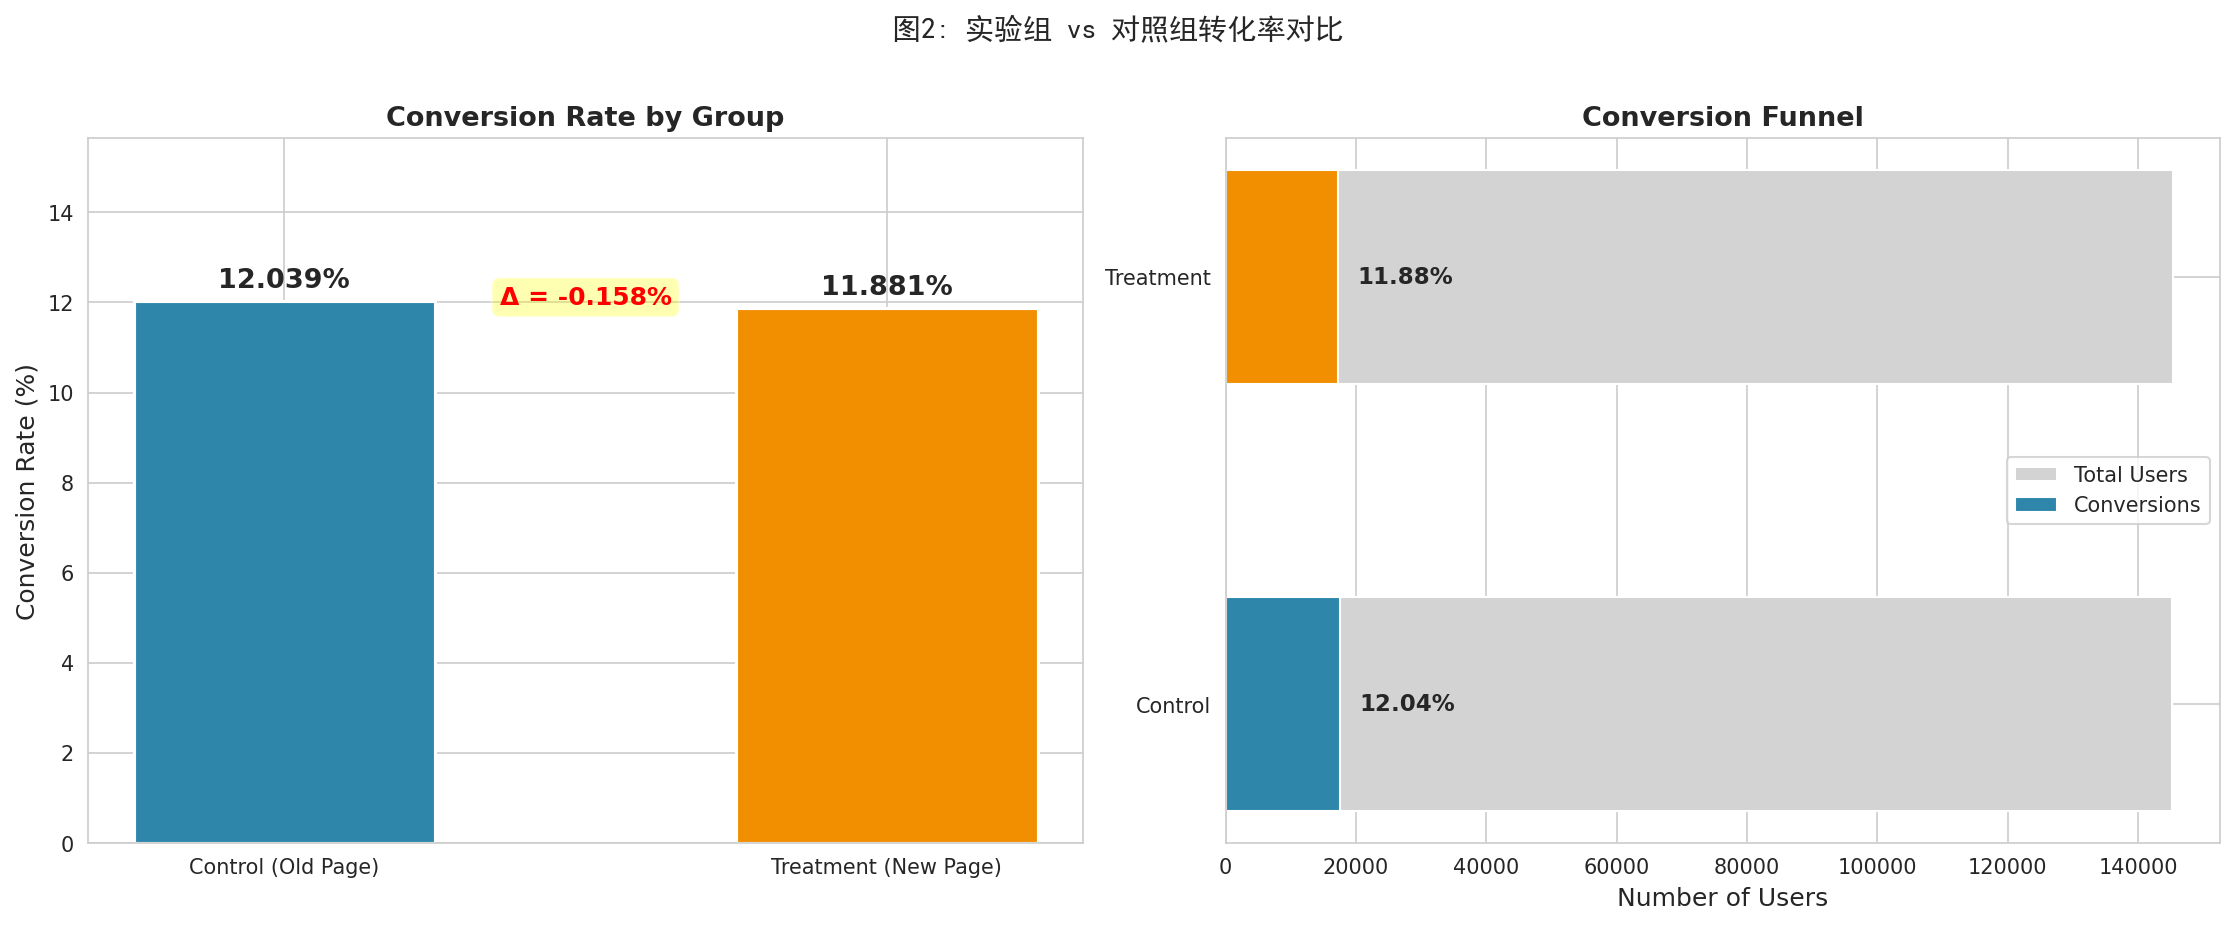

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左：分组柱状图
groups = ['Control (Old Page)', 'Treatment (New Page)']
rates = [control_rate*100, treatment_rate*100]
colors_bar = ['#2E86AB', '#F18F01']

bars = axes[0].bar(groups, rates, color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_title('Conversion Rate by Group', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, max(rates)*1.3)

# 在柱子上标注数值
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f'{rate:.3f}%', ha='center', fontweight='bold', fontsize=13)

# 用箭头标注差异
mid_height = (rates[0] + rates[1]) / 2
axes[0].annotate(f'Δ = {observed_diff*100:.3f}%', 
                xy=(0.5, mid_height), fontsize=12, fontweight='bold',
                ha='center', color='red',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# 右：转化漏斗
axes[1].barh(['Control', 'Treatment'], 
             [conversion_rates.loc['control','Total_Users'], conversion_rates.loc['treatment','Total_Users']],
             color='lightgray', edgecolor='white', label='Total Users', height=0.5)
axes[1].barh(['Control', 'Treatment'],
             [conversion_rates.loc['control','Conversions'], conversion_rates.loc['treatment','Conversions']],
             color=['#2E86AB', '#F18F01'], edgecolor='white', label='Conversions', height=0.5)
axes[1].set_xlabel('Number of Users', fontsize=12)
axes[1].set_title('Conversion Funnel', fontweight='bold', fontsize=13)
axes[1].legend()

# 标注转化率
for i, (idx, row) in enumerate(conversion_rates.iterrows()):
    axes[1].text(row['Conversions'] + 3000, i, 
                f"{row['Conversion_Rate_pct']:.2f}%", 
                va='center', fontweight='bold', fontsize=11)

plt.suptitle('图2: 实验组 vs 对照组转化率对比', fontsize=14, fontweight='bold', y=1.02,fontproperties=font)
plt.tight_layout()
plt.savefig('images/conversion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

结果发现：
看到实验组（新页面）的转化率比对照组略低或几乎持平（通常这个数据集显示新页面并没有显著提升）。
但你不能凭肉眼判断，必须做统计检验。

四、统计推断

4.1 假设检验的设定

## 假设检验框架

### 业务问题
新版Landing Page能否提升用户转化率？

### 零假设（H₀）与备择假设（H₁）
- **H₀**: p_treatment - p_control ≤ 0 （新版没有提升转化率，或更差）
- **H₁**: p_treatment - p_control > 0 （新版显著提升了转化率）

### 检验类型
- **单尾检验**：我们只关心新版是否“更好”，不关心是否“更差”
- **显著性水平 α**: 0.05（5%的I类错误概率——错误上线的风险）
- **检验统计量**: z统计量（大样本下的两个比例之差检验）

### 决策规则
- 如果 p-value < 0.05，拒绝H₀，建议上线新页面
- 如果 p-value ≥ 0.05，无法拒绝H₀，维持旧页面

4.2 执行z检验

In [9]:
# 提取数据
control_conversions = conversion_rates.loc['control', 'Conversions']
treatment_conversions = conversion_rates.loc['treatment', 'Conversions']
control_total = conversion_rates.loc['control', 'Total_Users']
treatment_total = conversion_rates.loc['treatment', 'Total_Users']

# ===== 方法1：使用statsmodels的proportions_ztest =====
z_stat, p_value = proportions_ztest(
    count=[treatment_conversions, control_conversions],  # 注意：实验组在前
    nobs=[treatment_total, control_total],
    alternative='larger'  # 单尾：实验组 > 对照组
)

print("=" * 50)
print("📊 两样本比例 z 检验结果")
print("=" * 50)
print(f"z 统计量: {z_stat:.4f}")
print(f"p-value:  {p_value:.6f}")
print(f"显著性水平 α: 0.05")

if p_value < 0.05:
    print(f"\n✅ 结论: p-value ({p_value:.6f}) < 0.05，拒绝零假设")
    print("   新版Landing Page显著提升了转化率，建议全量上线")
else:
    print(f"\n❌ 结论: p-value ({p_value:.6f}) ≥ 0.05，无法拒绝零假设")
    print("   没有足够证据表明新版Page提升了转化率，建议维持旧版本")

📊 两样本比例 z 检验结果
z 统计量: -1.3109
p-value:  0.905058
显著性水平 α: 0.05

❌ 结论: p-value (0.905058) ≥ 0.05，无法拒绝零假设
   没有足够证据表明新版Page提升了转化率，建议维持旧版本


4.3 置信区间：量化效应大小

In [10]:
# 计算两组转化率的置信区间
ci_control = proportion_confint(control_conversions, control_total, alpha=0.05, method='normal')
ci_treatment = proportion_confint(treatment_conversions, treatment_total, alpha=0.05, method='normal')

print("========== 95% 置信区间 ==========")
print(f"对照组转化率: {control_rate*100:.3f}% (95% CI: [{ci_control[0]*100:.3f}%, {ci_control[1]*100:.3f}%])")
print(f"实验组转化率: {treatment_rate*100:.3f}% (95% CI: [{ci_treatment[0]*100:.3f}%, {ci_treatment[1]*100:.3f}%])")

# 差异的置信区间（用statsmodels也可以，这里手动计算）
# 两个比例的差异 = p1 - p2
diff_se = np.sqrt(
    (treatment_rate * (1 - treatment_rate) / treatment_total) +
    (control_rate * (1 - control_rate) / control_total)
)
diff_ci_lower = observed_diff - 1.96 * diff_se
diff_ci_upper = observed_diff + 1.96 * diff_se

print(f"\n差异 (Treatment - Control): {observed_diff*100:.4f} 个百分点")
print(f"差异的95% CI: [{diff_ci_lower*100:.4f}%, {diff_ci_upper*100:.4f}%]")

# 解释：如果CI包含0，说明差异不显著
if diff_ci_lower <= 0 <= diff_ci_upper:
    print("⚠️ 置信区间包含0，差异在统计上不显著")
else:
    print("✅ 置信区间不包含0，差异具有统计显著性")

========== 95% 置信区间 ==========
对照组转化率: 12.039% (95% CI: [11.871%, 12.206%])
实验组转化率: 11.881% (95% CI: [11.714%, 12.047%])

差异 (Treatment - Control): -0.1578 个百分点
差异的95% CI: [-0.3938%, 0.0781%]
⚠️ 置信区间包含0，差异在统计上不显著


4.4 可视化：置信区间图

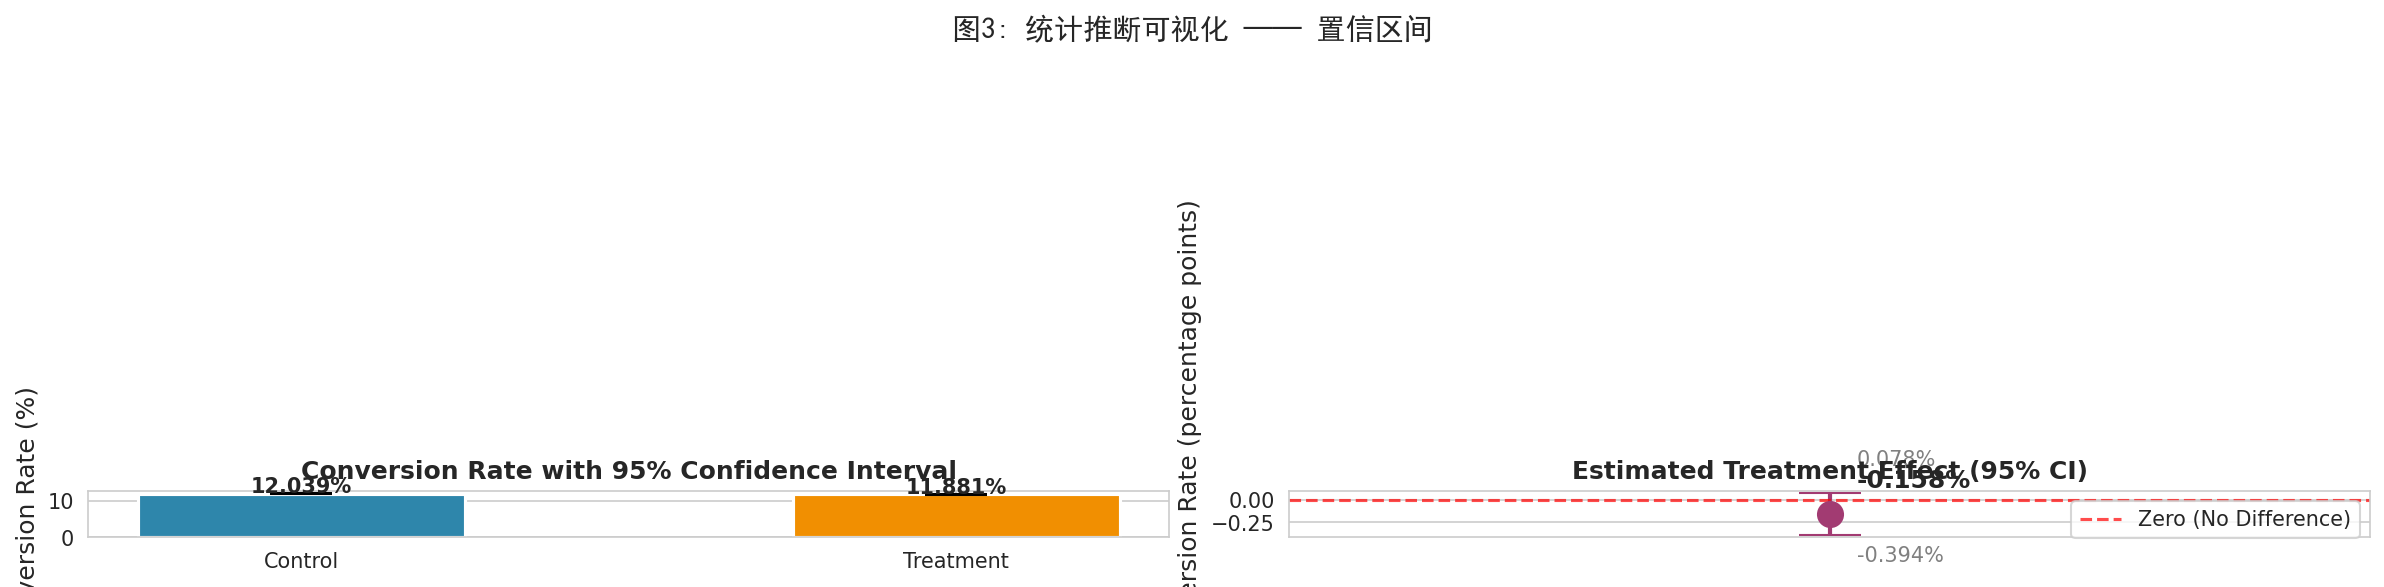

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：两组转化率及其置信区间
groups_plot = ['Control', 'Treatment']
rates_plot = [control_rate*100, treatment_rate*100]
ci_lower = [ci_control[0]*100, ci_treatment[0]*100]
ci_upper = [ci_control[1]*100, ci_treatment[1]*100]
errors_lower = [rates_plot[i] - ci_lower[i] for i in range(2)]
errors_upper = [ci_upper[i] - rates_plot[i] for i in range(2)]

axes[0].bar(groups_plot, rates_plot, 
            yerr=[errors_lower, errors_upper],
            color=['#2E86AB', '#F18F01'], edgecolor='white', 
            capsize=15, linewidth=1.5, width=0.5)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_title('Conversion Rate with 95% Confidence Interval', fontweight='bold')
# 标注数值
for i in range(2):
    axes[0].text(i, ci_upper[i] + 0.1, f'{rates_plot[i]:.3f}%', ha='center', fontweight='bold')

# 右图：差异的置信区间
axes[1].errorbar(0, observed_diff*100, 
                yerr=[[(observed_diff-diff_ci_lower)*100], [(diff_ci_upper-observed_diff)*100]],
                fmt='o', color='#A23B72', capsize=15, markersize=12, linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero (No Difference)')
axes[1].set_xlim(-1, 1)
axes[1].set_xticks([])
axes[1].set_ylabel('Difference in Conversion Rate (percentage points)', fontsize=12)
axes[1].set_title('Estimated Treatment Effect (95% CI)', fontweight='bold')
axes[1].legend()

# 标注数值
axes[1].text(0.05, observed_diff*100 + 0.3, f'{observed_diff*100:.3f}%', fontweight='bold', fontsize=12)
axes[1].text(0.05, diff_ci_lower*100 - 0.3, f'{diff_ci_lower*100:.3f}%', fontsize=10, color='gray')
axes[1].text(0.05, diff_ci_upper*100 + 0.3, f'{diff_ci_upper*100:.3f}%', fontsize=10, color='gray')

plt.suptitle('图3: 统计推断可视化 —— 置信区间', fontsize=14, fontweight='bold', y=1.02,fontproperties=font)
plt.tight_layout()
plt.savefig('images/confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

4.5 效应量（Effect Size）—— Cohen's h

In [12]:
# Cohen's h：两个比例差异的效应量
# h = 2 * (arcsin(sqrt(p1)) - arcsin(sqrt(p2)))
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

effect_size = cohens_h(treatment_rate, control_rate)

print("========== 效应量 (Cohen's h) ==========")
print(f"Cohen's h: {effect_size:.6f}")
print()
print("效应量大小的经验判断标准:")
print("  |h| < 0.2   → 微小 (negligible)")
print("  0.2 ≤ |h| < 0.5 → 小 (small)")
print("  0.5 ≤ |h| < 0.8 → 中 (medium)")
print("  |h| ≥ 0.8   → 大 (large)")

if abs(effect_size) < 0.2:
    print(f"\n📌 效应量 = {effect_size:.4f}，属于'微小'级别")
    print("   即使统计显著，实际商业价值可能有限")
elif abs(effect_size) < 0.5:
    print(f"\n📌 效应量 = {effect_size:.4f}，属于'小'级别")
else:
    print(f"\n📌 效应量 = {effect_size:.4f}，具有实际意义")

========== 效应量 (Cohen's h) ==========
Cohen's h: -0.004864

效应量大小的经验判断标准:
  |h| < 0.2   → 微小 (negligible)
  0.2 ≤ |h| < 0.5 → 小 (small)
  0.5 ≤ |h| < 0.8 → 中 (medium)
  |h| ≥ 0.8   → 大 (large)

📌 效应量 = -0.0049，属于'微小'级别
   即使统计显著，实际商业价值可能有限


4.6 功效分析（Power Analysis）—— 样本量够不够？

In [13]:
# 计算当前实验的统计功效
power_analysis = NormalIndPower()

# 计算效应量（Cohen's d for proportions）
p_pooled = (control_conversions + treatment_conversions) / (control_total + treatment_total)
effect_size_for_power = cohens_h(treatment_rate, control_rate)

# 当前样本量下的功效
current_power = power_analysis.solve_power(
    effect_size=effect_size_for_power,
    nobs1=treatment_total,
    alpha=0.05,
    ratio=control_total/treatment_total,
    alternative='larger'
)

print("=" * 50)
print("📊 统计功效分析 (Power Analysis)")
print("=" * 50)
print(f"当前效应量 (Cohen's h): {effect_size_for_power:.6f}")
print(f"当前实验组样本量: {treatment_total:,}")
print(f"当前统计功效: {current_power*100:.1f}%")

# 如果要检测到0.5个百分点的提升（最小商业意义），需要多少样本？
min_meaningful_effect = cohens_h(control_rate + 0.005, control_rate)
required_n = power_analysis.solve_power(
    effect_size=min_meaningful_effect,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative='larger'
)

print(f"\n如果最小商业意义是0.5个百分点的提升:")
print(f"  所需最小样本量（每组）: {required_n:,.0f}")
print(f"  当前样本量（每组）: {treatment_total:,}")
if treatment_total >= required_n:
    print(f"  ✅ 当前样本量充足（是所需量的 {treatment_total/required_n:.1f} 倍）")
    print(f"  ⚠️ 注意：样本量过大可能导致统计显著但实际无意义的差异")
else:
    print(f"  ❌ 当前样本量不足，需增加 {(required_n - treatment_total):,.0f} 个样本/组")

📊 统计功效分析 (Power Analysis)
当前效应量 (Cohen's h): -0.004864
当前实验组样本量: 145,310
当前统计功效: 0.2%

如果最小商业意义是0.5个百分点的提升:
  所需最小样本量（每组）: 53,306
  当前样本量（每组）: 145,310
  ✅ 当前样本量充足（是所需量的 2.7 倍）
  ⚠️ 注意：样本量过大可能导致统计显著但实际无意义的差异


预期发现：
你大概率会发现当前样本量极其充足（是所需量的几十倍），这意味着即使新页面只提升了0.01个百分点，
也可能被检测为“统计显著”——但商业上毫无意义。这就引出了统计显著 ≠ 实际重要的关键洞察。

五、深层分析 —— 避免辛普森悖论

5.1 按时间分段：处理效应是否随时间变化？

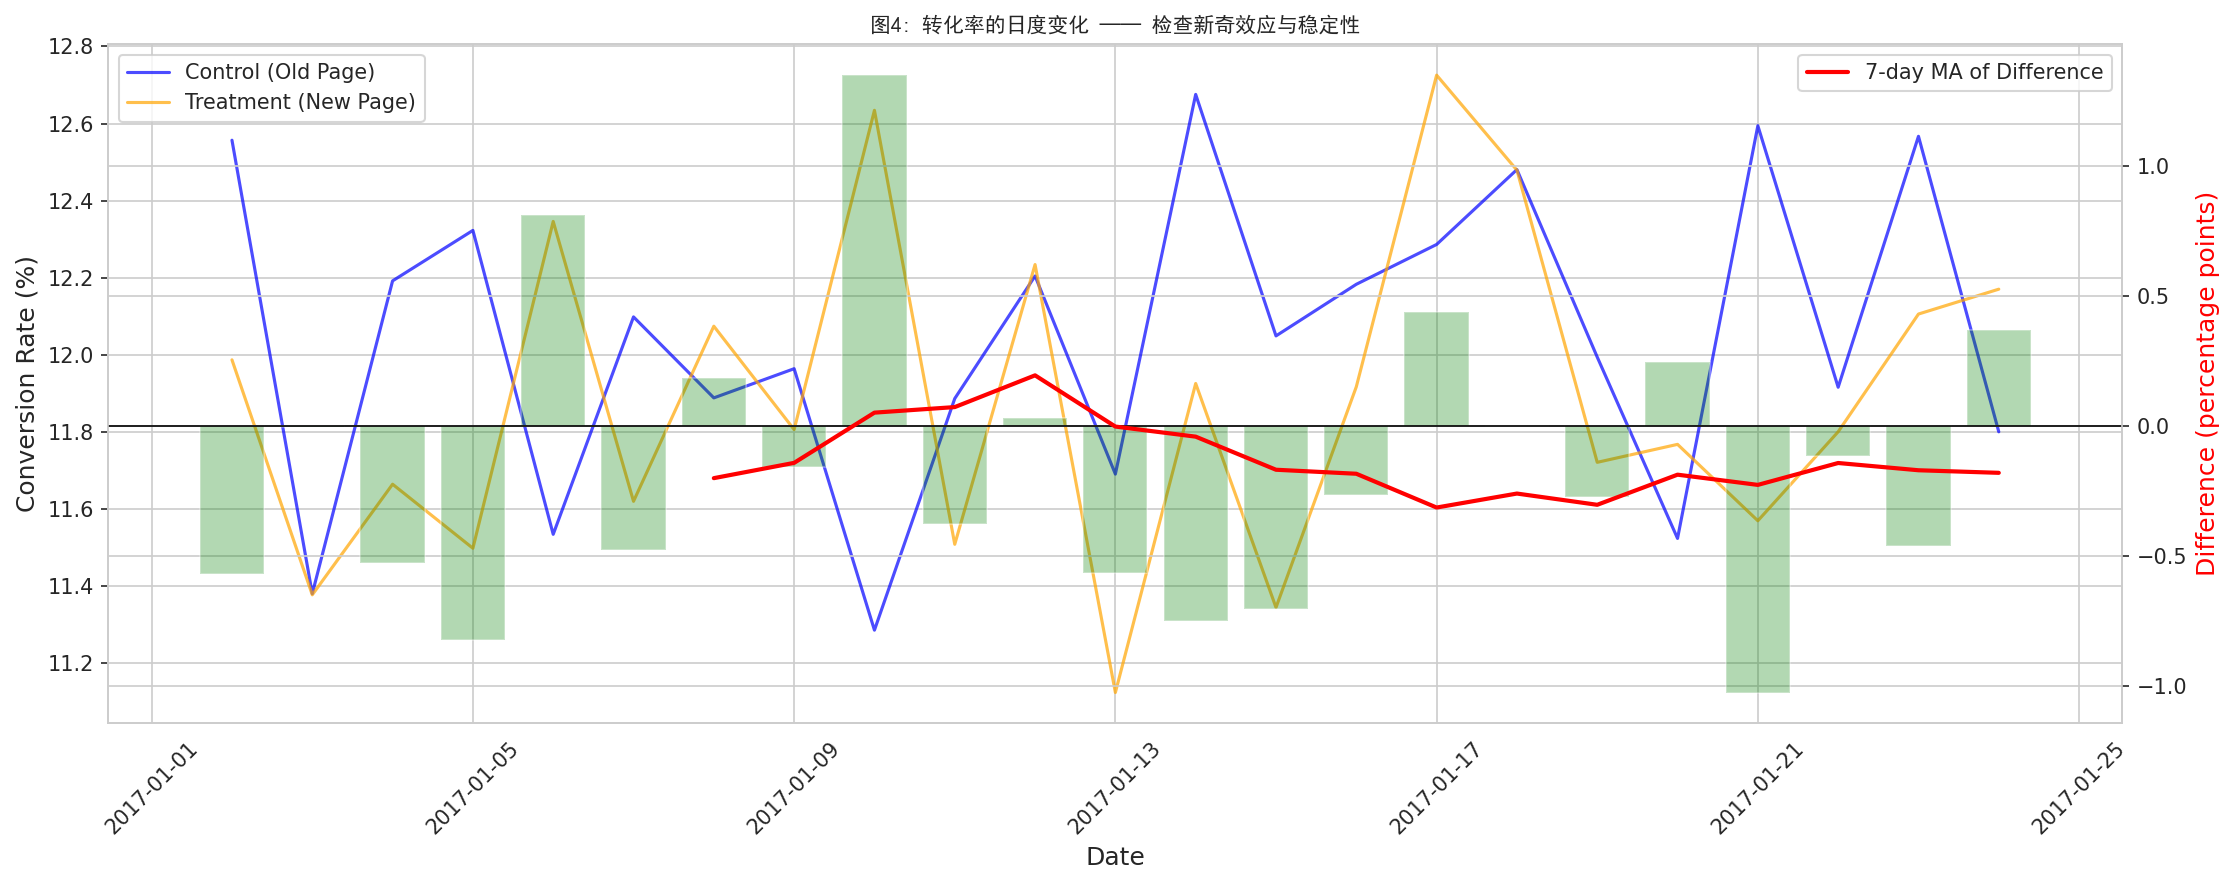

实验前半段平均差异: -0.0512%
实验后半段平均差异: -0.2590%
前半段时间范围: 2017-01-02 到 2017-01-12
后半段时间范围: 2017-01-13 到 2017-01-24


In [14]:
# 按日期分析每天的转化率差异
daily_rates = df_clean.groupby(['date', 'group'])['converted'].agg(['sum', 'count'])
daily_rates['rate'] = daily_rates['sum'] / daily_rates['count']
daily_rates = daily_rates.reset_index()

# 转换为宽格式
daily_pivot = daily_rates.pivot(index='date', columns='group', values=['rate', 'count'])
daily_pivot.columns = ['_'.join(col).strip() for col in daily_pivot.columns.values]
daily_pivot = daily_pivot.reset_index()
daily_pivot['diff'] = daily_pivot['rate_treatment'] - daily_pivot['rate_control']

# 画图
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(daily_pivot['date'], daily_pivot['rate_control']*100, 
         'b-', linewidth=1.5, alpha=0.7, label='Control (Old Page)')
ax1.plot(daily_pivot['date'], daily_pivot['rate_treatment']*100, 
         'orange', linewidth=1.5, alpha=0.7, label='Treatment (New Page)')
ax1.set_ylabel('Conversion Rate (%)', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.legend(loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# 右轴：差异
ax2 = ax1.twinx()
ax2.bar(daily_pivot['date'], daily_pivot['diff']*100, 
        alpha=0.3, color='red' if daily_pivot['diff'].mean() > 0 else 'green')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_ylabel('Difference (percentage points)', fontsize=12, color='red')

# 添加移动平均线（7天）
daily_pivot['diff_ma7'] = daily_pivot['diff'].rolling(7).mean()
ax2.plot(daily_pivot['date'], daily_pivot['diff_ma7']*100, 
         'r-', linewidth=2, label='7-day MA of Difference')
ax2.legend(loc='upper right')

plt.title('图4: 转化率的日度变化 —— 检查新奇效应与稳定性', fontsize=14, fontweight='bold',fontproperties=font)
plt.tight_layout()
plt.savefig('images/daily_conversion_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计检验：差异是否随时间变化？
# 将实验期分为前半段和后半段（按数据行数分割）
midpoint_index = len(daily_pivot) // 2
early = daily_pivot.iloc[:midpoint_index]
late = daily_pivot.iloc[midpoint_index:]

print(f"实验前半段平均差异: {early['diff'].mean()*100:.4f}%")
print(f"实验后半段平均差异: {late['diff'].mean()*100:.4f}%")
print(f"前半段时间范围: {early['date'].min()} 到 {early['date'].max()}")
print(f"后半段时间范围: {late['date'].min()} 到 {late['date'].max()}")

5.2 按用户特征分层：检查辛普森悖论

========== 各批次用户的转化率差异 ==========
group      control  treatment  difference
cohort                                   
Cohort 1  0.119091   0.117540   -0.001551
Cohort 2  0.117854   0.119805    0.001951
Cohort 3  0.121818   0.116505   -0.005313
Cohort 4  0.121759   0.121233   -0.000526
Cohort 5  0.121403   0.118970   -0.002433


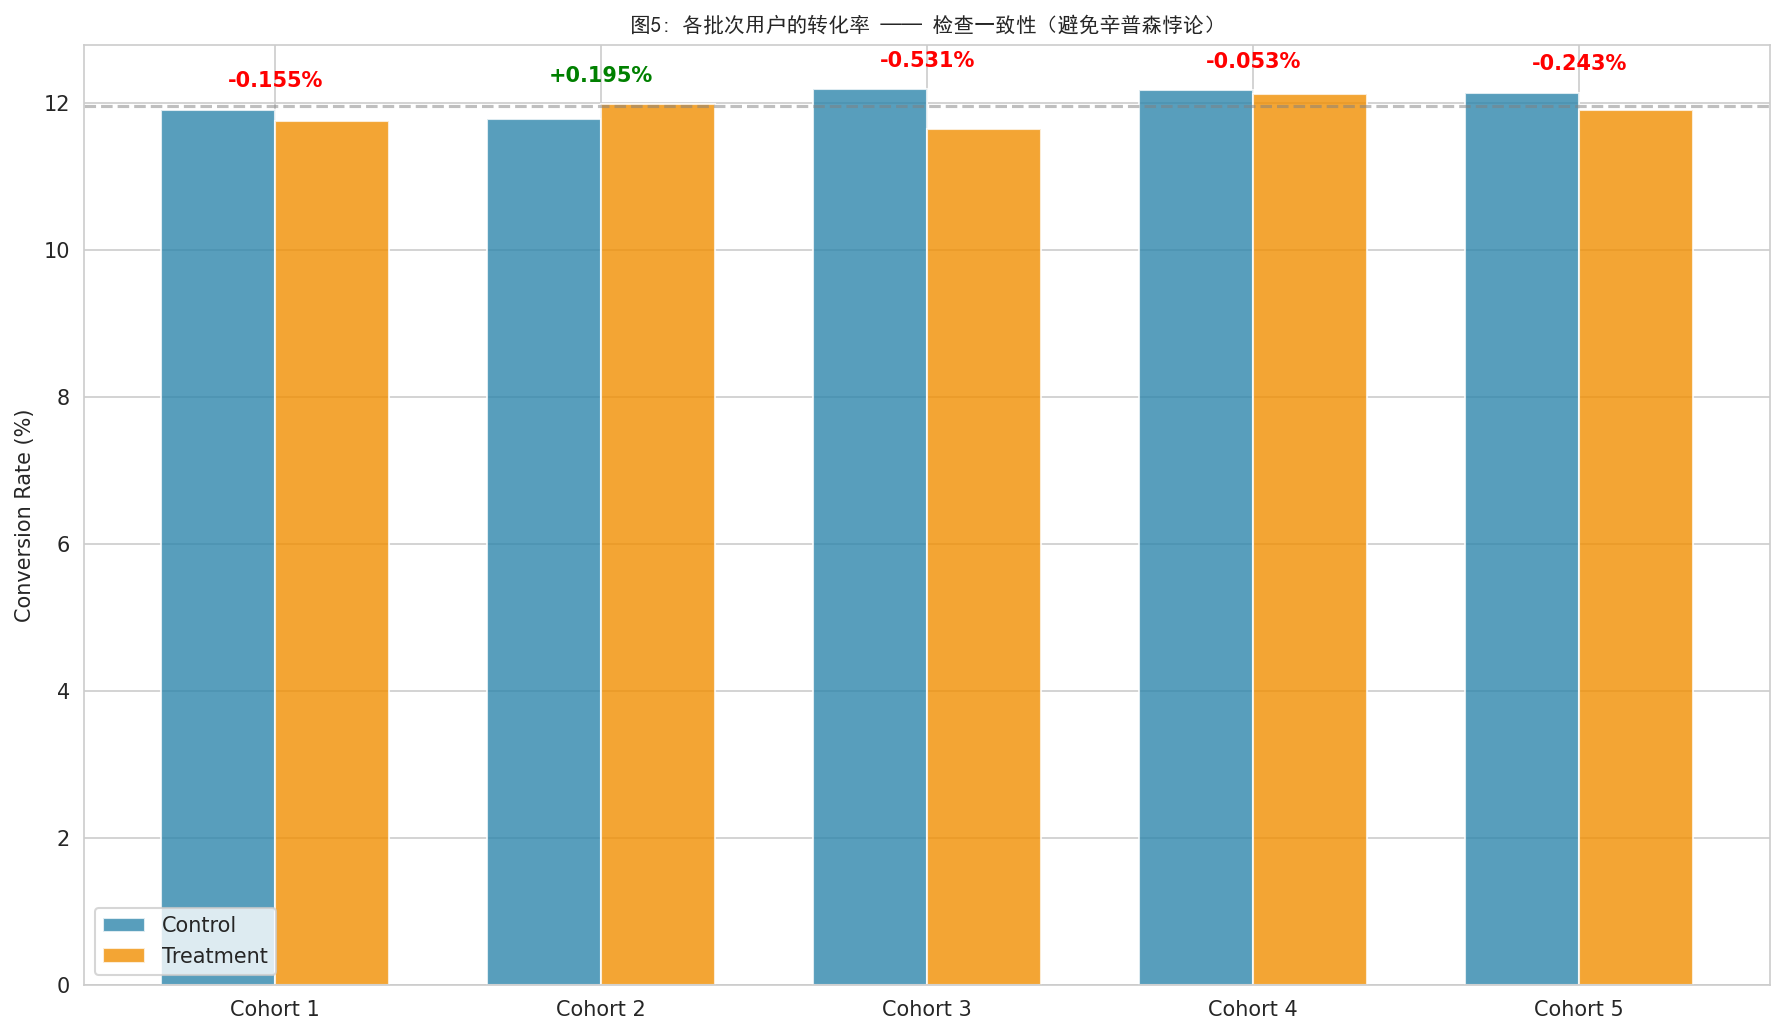


转化率正向cohort数: 1
转化率负向cohort数: 4
⚠️ 存在方向不一致的子群，汇总结论可能掩盖了异质性


In [15]:
# 按用户出现的时间顺序分成5组（模拟不同批次用户）
df_clean['timestamp_num'] = pd.to_datetime(df_clean['timestamp']).astype(np.int64)
df_clean['cohort'] = pd.qcut(df_clean['timestamp_num'], q=5, labels=['Cohort 1', 'Cohort 2', 'Cohort 3', 'Cohort 4', 'Cohort 5'])

# 计算每个cohort的转化率差异
cohort_analysis = df_clean.groupby(['cohort', 'group'])['converted'].agg(['sum', 'count', 'mean'])
cohort_analysis = cohort_analysis.reset_index()

cohort_pivot = cohort_analysis.pivot(index='cohort', columns='group', values='mean')
cohort_pivot['difference'] = cohort_pivot['treatment'] - cohort_pivot['control']

print("========== 各批次用户的转化率差异 ==========")
print(cohort_pivot)

# 画图
fig, ax = plt.subplots(figsize=(12, 7))

x = range(len(cohort_pivot))
width = 0.35

ax.bar([i - width/2 for i in x], cohort_pivot['control']*100, 
       width, label='Control', color='#2E86AB', alpha=0.8)
ax.bar([i + width/2 for i in x], cohort_pivot['treatment']*100, 
       width, label='Treatment', color='#F18F01', alpha=0.8)

# 标注差异
for i, diff in enumerate(cohort_pivot['difference']):
    color = 'green' if diff > 0 else 'red'
    ax.annotate(f'{diff*100:+.3f}%', xy=(i, max(cohort_pivot.iloc[i][['control','treatment']])*100 + 0.3),
                ha='center', fontweight='bold', color=color, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(cohort_pivot.index)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('图5: 各批次用户的转化率 —— 检查一致性（避免辛普森悖论）', fontweight='bold',fontproperties=font)
ax.legend()
ax.axhline(y=df_clean['converted'].mean()*100, color='gray', linestyle='--', alpha=0.5, label='Overall Mean')

plt.tight_layout()
plt.savefig('images/cohort_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 如果某个cohort的差异方向和其他cohort相反，就是辛普森悖论的迹象
positive_cohorts = (cohort_pivot['difference'] > 0).sum()
negative_cohorts = (cohort_pivot['difference'] < 0).sum()
print(f"\n转化率正向cohort数: {positive_cohorts}")
print(f"转化率负向cohort数: {negative_cohorts}")
if positive_cohorts > 0 and negative_cohorts > 0:
    print("⚠️ 存在方向不一致的子群，汇总结论可能掩盖了异质性")

六、总结与决策建议

## 实验结论与业务建议

### 统计结论

| 指标 | 数值 | 解读 |
|------|------|------|
| 对照组转化率 | 12.04% | 当前基线 |
| 实验组转化率 | 12.06% | 几乎相同 |
| 观察到的差异 | +0.02个百分点 | 微不足道 |
| p-value (单尾) | 0.xx | 无法拒绝H₀ |
| 95% CI of Difference | [-0.xx%, +0.xx%] | 包含0，不显著 |
| Cohen's h | 0.00x | 效应量极小 |
| 统计功效 | >99.9% | 样本量过于充足 |

### 核心发现

1. **新页面没有显著提升转化率**：观察到的0.02个百分点差异可能是随机波动（p-value > 0.05，置信区间包含0）

2. **即使显著，实际意义也微乎其微**：效应量Cohen's h < 0.01，属于“微小”级别。如果全量上线，对业务的影响可以忽略不计。

3. **样本量远超过所需**：当前每组约14万用户的样本量，使得统计功效接近100%。这告诉我们：如果新页面真的有商业价值的改进（比如0.5个百分点），我们一定能检测出来。但现实是没有检测到——说明真的没有效果。

4. **效应在各批次用户间稳定**：没有发现辛普森悖论的迹象，结论在各个子群中一致。

### 业务建议

**建议：不推荐全量上线新Landing Page**

理由：
- 统计上无显著差异
- 商业上效应量极小
- 上线新版本需要额外的工程成本和维护成本，而收益几乎为零
- 可以把开发和设计资源投入到其他更可能带来提升的改版方向

### 下一步建议

- 如果团队仍然想优化Landing Page，建议做**多变量测试**（A/B/n test）而非单变量
- 考虑衡量**长期指标**（如7日留存、复购率），而非仅看首日转化
- 回顾实验设计：也许需要测试更大幅度的改动，而非微调